## Predicting Customer Subscription to a Bank Term Deposit Using Machine Learning

### 1. Loading the Dataset

In [59]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv('bank-additional-full.csv', sep=';')

# Quick overview
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nBasic Statistics:")
print(df.describe())

Shape: (41188, 21)

First 5 rows:
   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   
3   may         mon  ...         1    999         0  nonexistent          1.1   
4   may         mon  ...         1    999         0  nonexistent          1.1   

   cons.price.idx  con

### 2. Exploratory Data Analysis

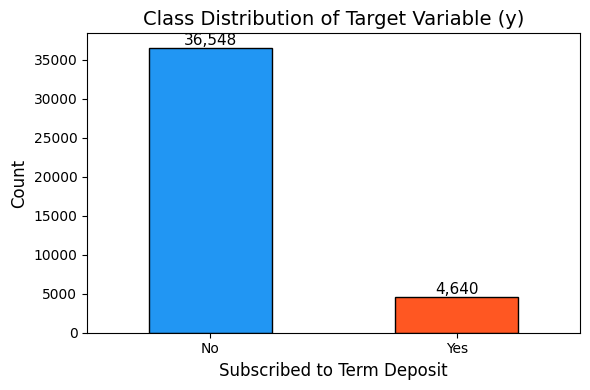

In [60]:
# Chart 1 - Class Distribution
plt.figure(figsize=(6,4))
ax = df['y'].value_counts().plot(kind='bar', color=['#2196F3', '#FF5722'], edgecolor='black')
plt.title('Class Distribution of Target Variable (y)', fontsize=14)
plt.xlabel('Subscribed to Term Deposit', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(ticks=[0,1], labels=['No', 'Yes'], rotation=0)
for p in ax.patches:
    ax.annotate(f'{p.get_height():,}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.savefig('chart1_class_distribution.png')
plt.show()

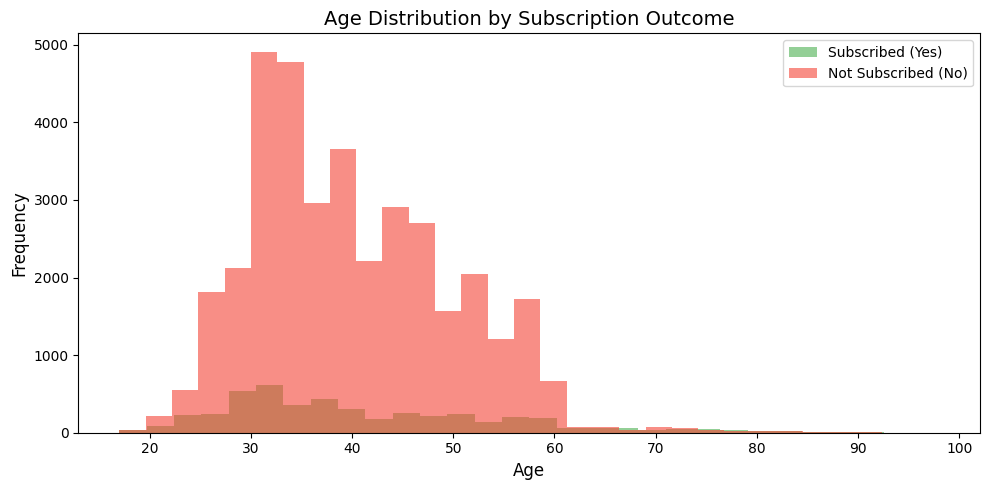

In [61]:
# Chart 2 - Age Distribution by Subscription
plt.figure(figsize=(10,5))
df[df['y']=='yes']['age'].plot(kind='hist', bins=30, alpha=0.6, color='#4CAF50', label='Subscribed (Yes)')
df[df['y']=='no']['age'].plot(kind='hist', bins=30, alpha=0.6, color='#F44336', label='Not Subscribed (No)')
plt.title('Age Distribution by Subscription Outcome', fontsize=14)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig('chart2_age_distribution.png')
plt.show()

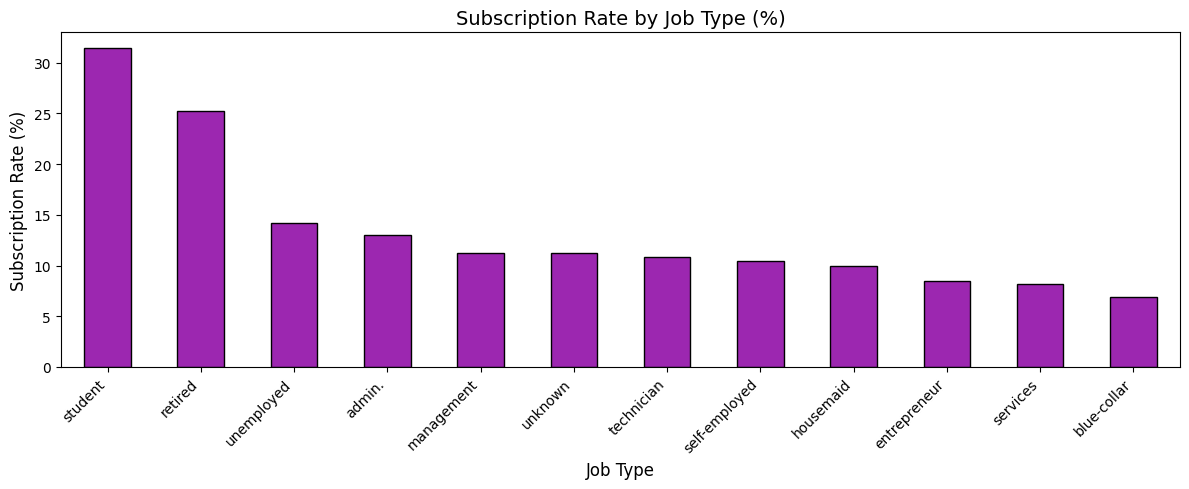

In [62]:
# Chart 3 - Subscription Rate by Job Type
plt.figure(figsize=(12,5))
job_sub = df.groupby('job')['y'].apply(lambda x: (x=='yes').sum()/len(x)*100).sort_values(ascending=False)
job_sub.plot(kind='bar', color='#9C27B0', edgecolor='black')
plt.title('Subscription Rate by Job Type (%)', fontsize=14)
plt.xlabel('Job Type', fontsize=12)
plt.ylabel('Subscription Rate (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('chart3_subscription_by_job.png')
plt.show()

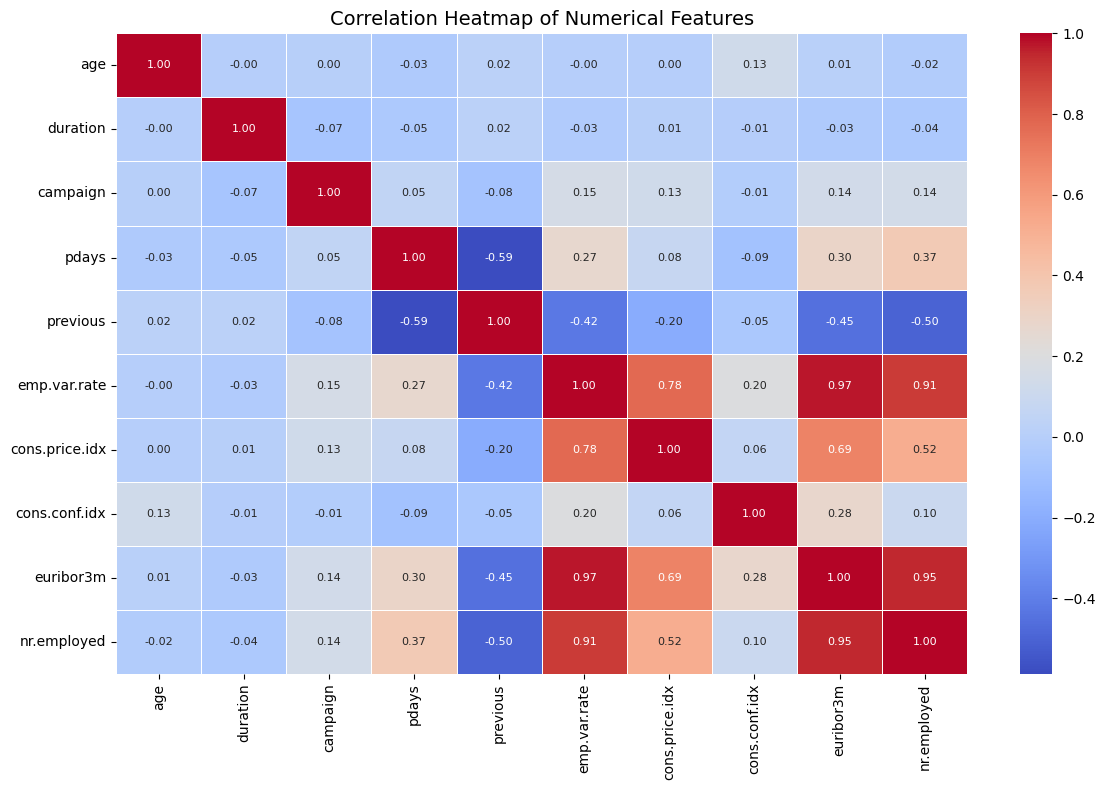

In [63]:
# Chart 4 - Correlation Heatmap of Numerical Features
plt.figure(figsize=(12,8))
numerical_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size': 8})
plt.title('Correlation Heatmap of Numerical Features', fontsize=14)
plt.tight_layout()
plt.savefig('chart4_correlation_heatmap.png')
plt.show()

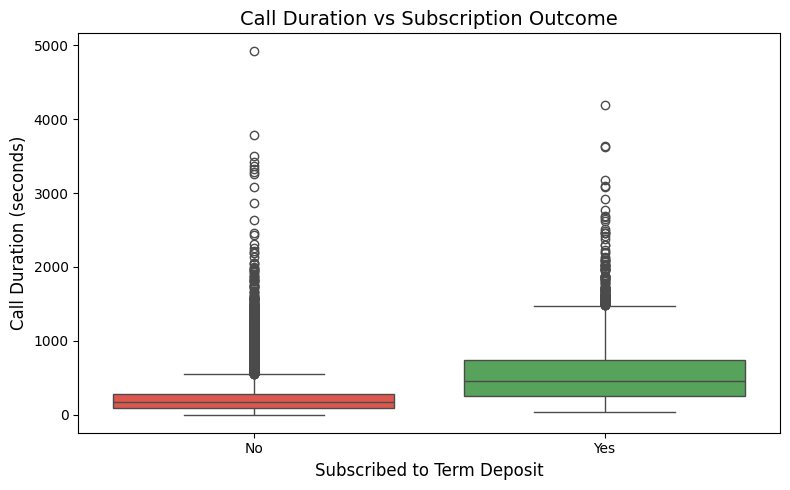

In [64]:
# Chart 5 - Call Duration vs Subscription Outcome
plt.figure(figsize=(8,5))
sns.boxplot(x='y', y='duration', data=df, palette={'yes':'#4CAF50', 'no':'#F44336'})
plt.title('Call Duration vs Subscription Outcome', fontsize=14)
plt.xlabel('Subscribed to Term Deposit', fontsize=12)
plt.ylabel('Call Duration (seconds)', fontsize=12)
plt.xticks(ticks=[0,1], labels=['No', 'Yes'])
plt.tight_layout()
plt.savefig('chart5_duration_vs_subscription.png')
plt.show()

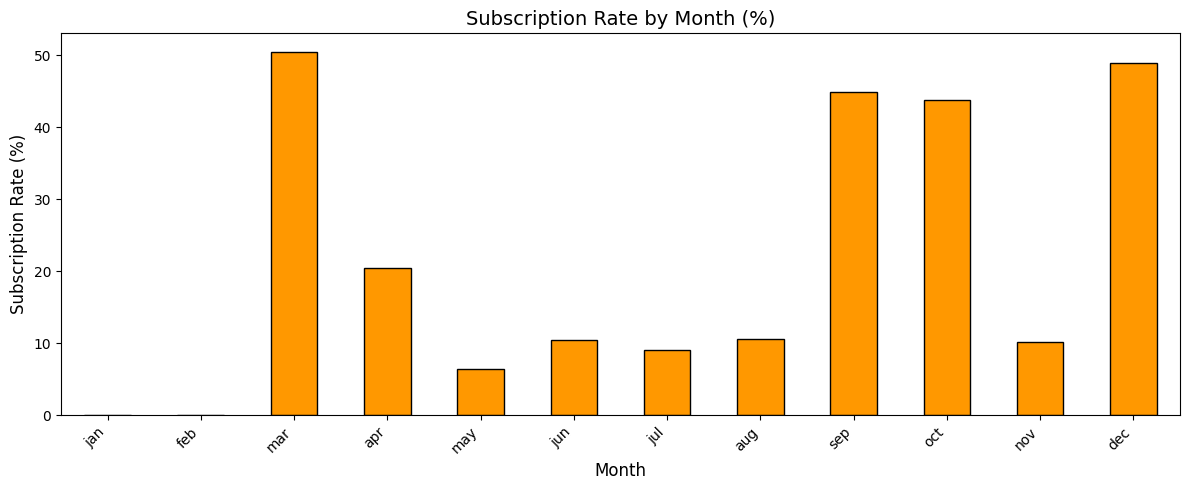

In [65]:
# Chart 6 - Subscription Rate by Month
plt.figure(figsize=(12,5))
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
month_sub = df.groupby('month')['y'].apply(lambda x: (x=='yes').sum()/len(x)*100).reindex(month_order)
month_sub.plot(kind='bar', color='#FF9800', edgecolor='black')
plt.title('Subscription Rate by Month (%)', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Subscription Rate (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('chart6_subscription_by_month.png')
plt.show()

### 3. Data Cleaning & Preprocessing

In [66]:
# Step 1 - Check duplicates and drop duration = 0
print("Duplicates:", df.duplicated().sum())
print("Rows with duration = 0:", (df['duration'] == 0).sum())

# Drop rows where duration = 0
df = df[df['duration'] > 0]
print("Shape after dropping duration = 0:", df.shape)

Duplicates: 12
Rows with duration = 0: 4
Shape after dropping duration = 0: (41184, 21)


In [67]:
# Step 2 - Drop duplicates and handle pdays = 999
df = df.drop_duplicates()
print("Shape after dropping duplicates:", df.shape)

# Replace pdays = 999 with 0 (means never previously contacted)
df['pdays'] = df['pdays'].replace(999, 0)
print("\nPdays value counts after replacement:")
print(df['pdays'].value_counts().head())

Shape after dropping duplicates: (41172, 21)

Pdays value counts after replacement:
pdays
0    39672
3      439
6      412
4      118
9       64
Name: count, dtype: int64


In [68]:
# Step 3 - Drop highly correlated features
# From heatmap we saw emp.var.rate, euribor3m and nr.employed are highly correlated
# We keep euribor3m as it is the most commonly used economic indicator
df = df.drop(columns=['emp.var.rate', 'nr.employed'])
print("Shape after dropping correlated features:", df.shape)
print("\nRemaining columns:")
print(df.columns.tolist())

Shape after dropping correlated features: (41172, 19)

Remaining columns:
['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'y']


In [69]:
# Step 4 - Encode categorical variables
# Binary columns - Label Encoding
binary_cols = ['default', 'housing', 'loan', 'contact']
le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

# Target variable - Label Encoding
df['y'] = le.fit_transform(df['y'])

# Multi-class columns - One Hot Encoding
multi_cols = ['job', 'marital', 'education', 'month', 'day_of_week', 'poutcome']
df = pd.get_dummies(df, columns=multi_cols)

print("Shape after encoding:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

Shape after encoding: (41172, 55)

First 5 rows:
   age  default  housing  loan  contact  duration  campaign  pdays  previous  \
0   56        0        0     0        1       261         1      0         0   
1   57        1        0     0        1       149         1      0         0   
2   37        0        2     0        1       226         1      0         0   
3   40        0        0     0        1       151         1      0         0   
4   56        0        0     2        1       307         1      0         0   

   cons.price.idx  ...  month_oct  month_sep  day_of_week_fri  \
0          93.994  ...      False      False            False   
1          93.994  ...      False      False            False   
2          93.994  ...      False      False            False   
3          93.994  ...      False      False            False   
4          93.994  ...      False      False            False   

   day_of_week_mon  day_of_week_thu  day_of_week_tue  day_of_week_wed  \
0     

In [70]:
# Save label encoders for deployment
# Re-fit on original string values before they were encoded

le_default = LabelEncoder().fit(['no', 'unknown', 'yes'])
le_housing = LabelEncoder().fit(['no', 'unknown', 'yes'])
le_loan    = LabelEncoder().fit(['no', 'unknown', 'yes'])
le_contact = LabelEncoder().fit(['cellular', 'telephone'])

with open('label_encoders.pkl', 'wb') as f:
    pickle.dump({
        'default': le_default,
        'housing': le_housing,
        'loan':    le_loan,
        'contact': le_contact
    }, f)

# Verify the mappings so you can confirm they match
for col, le in [('default', le_default), ('housing', le_housing),
                ('loan', le_loan), ('contact', le_contact)]:
    print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

default: {np.str_('no'): np.int64(0), np.str_('unknown'): np.int64(1), np.str_('yes'): np.int64(2)}
housing: {np.str_('no'): np.int64(0), np.str_('unknown'): np.int64(1), np.str_('yes'): np.int64(2)}
loan: {np.str_('no'): np.int64(0), np.str_('unknown'): np.int64(1), np.str_('yes'): np.int64(2)}
contact: {np.str_('cellular'): np.int64(0), np.str_('telephone'): np.int64(1)}


In [71]:
# Step 5 - Handle class imbalance using class weights
# Separate features and target
X = df.drop(columns=['y'])
y = df['y']

print("Class distribution:")
print(y.value_counts())
print("\nClass distribution (%):")
print(y.value_counts(normalize=True)*100)

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nTraining set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("\nTraining set class distribution:")
print(y_train.value_counts())

Class distribution:
y
0    36533
1     4639
Name: count, dtype: int64

Class distribution (%):
y
0    88.732634
1    11.267366
Name: proportion, dtype: float64

Training set shape: (32937, 54)
Test set shape: (8235, 54)

Training set class distribution:
y
0    29242
1     3695
Name: count, dtype: int64


In [72]:
# Save cleaned dataset
df.to_csv('bank_cleaned.csv', index=False)
print("Dataset saved successfully!")
print("Shape:", df.shape)

Dataset saved successfully!
Shape: (41172, 55)


### 4. Logistic Regression & Random Forest Models

In [ ]:
# Model 1 - Logistic Regression with scaling
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train model
lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=5000)
lr.fit(X_train_scaled, y_train)

# Predictions
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:,1]

# Metrics
print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))
print("AUC-ROC:", roc_auc_score(y_test, y_prob_lr))

=== Logistic Regression ===
Accuracy: 0.8613236187006679

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.86      0.92      7291
           1       0.45      0.88      0.59       944

    accuracy                           0.86      8235
   macro avg       0.71      0.87      0.76      8235
weighted avg       0.92      0.86      0.88      8235

AUC-ROC: 0.9356731017344345


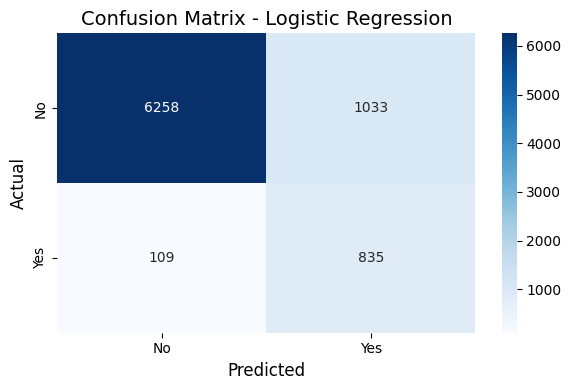

In [ ]:
# Confusion Matrix - Logistic Regression
plt.figure(figsize=(6,4))
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No', 'Yes'],
            yticklabels=['No', 'Yes'])
plt.title('Confusion Matrix - Logistic Regression', fontsize=14)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix_lr.png')
plt.show()

In [ ]:
# Model 2 - Random Forest
from sklearn.ensemble import RandomForestClassifier

# Train model
rf = RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=100)
rf.fit(X_train, y_train)

# Predictions
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

# Metrics
print("=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))
print("AUC-ROC:", roc_auc_score(y_test, y_prob_rf))

=== Random Forest ===
Accuracy: 0.9126897389192471

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.98      0.95      7291
           1       0.70      0.42      0.52       944

    accuracy                           0.91      8235
   macro avg       0.81      0.70      0.74      8235
weighted avg       0.90      0.91      0.90      8235

AUC-ROC: 0.943052033038178


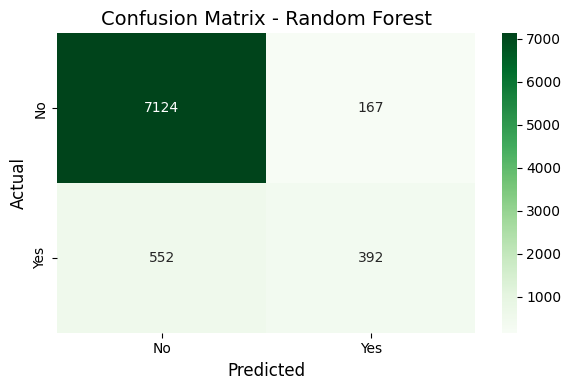

In [ ]:
# Confusion Matrix - Random Forest
plt.figure(figsize=(6,4))
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No', 'Yes'],
            yticklabels=['No', 'Yes'])
plt.title('Confusion Matrix - Random Forest', fontsize=14)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix_rf.png')
plt.show()

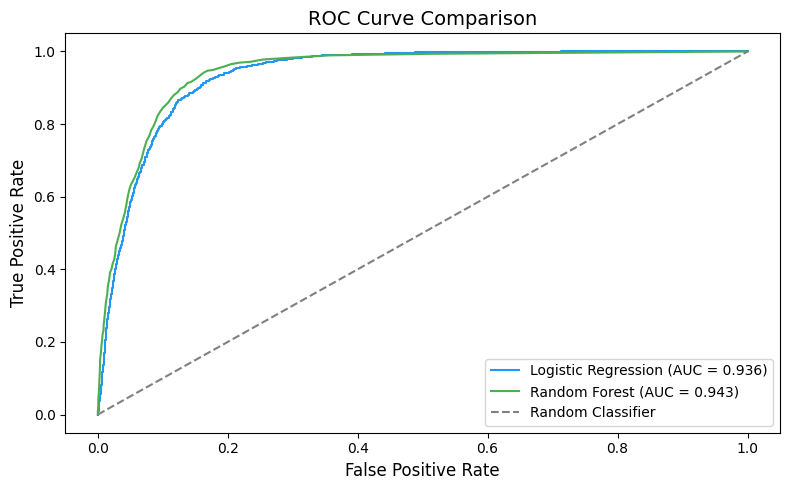

In [ ]:
# ROC Curve - Both Models
plt.figure(figsize=(8,5))
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.plot(fpr_lr, tpr_lr, color='#2196F3', label=f'Logistic Regression (AUC = 0.936)')
plt.plot(fpr_rf, tpr_rf, color='#4CAF50', label=f'Random Forest (AUC = 0.943)')
plt.plot([0,1], [0,1], color='gray', linestyle='--', label='Random Classifier')
plt.title('ROC Curve Comparison', fontsize=14)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve_comparison.png')
plt.show()

### 5. XGBoost & LightGBM Models

In [78]:
# Model 3 - XGBoost with tuning
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
import warnings
warnings.filterwarnings("ignore")

# Calculate scale_pos_weight to handle class imbalance
# This is the ratio of negative to positive samples
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

# Parameter grid - focused on what actually matters
xgb_param_grid = {
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [3, 4, 5, 6],
    "n_estimators": [100, 200, 300],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0]
}

# RandomizedSearchCV - more efficient than GridSearch
xgb_base = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss",
    use_label_encoder=False
)

xgb_search = RandomizedSearchCV(
    xgb_base,
    param_distributions=xgb_param_grid,
    n_iter=20,
    scoring="recall",  # Optimizing for recall - missing a subscriber is costlier than a false positive
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_train, y_train)
print("Best XGBoost params:", xgb_search.best_params_)

# Best model predictions
xgb = xgb_search.best_estimator_
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:,1]

print("=== XGBoost ===")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Classification Report:")
print(classification_report(y_test, y_pred_xgb))
print("AUC-ROC:", roc_auc_score(y_test, y_prob_xgb))

scale_pos_weight: 7.91
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best XGBoost params: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
=== XGBoost ===
Accuracy: 0.8471159684274439
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.84      0.91      7291
           1       0.42      0.94      0.59       944

    accuracy                           0.85      8235
   macro avg       0.71      0.89      0.75      8235
weighted avg       0.93      0.85      0.87      8235

AUC-ROC: 0.9472269910198085


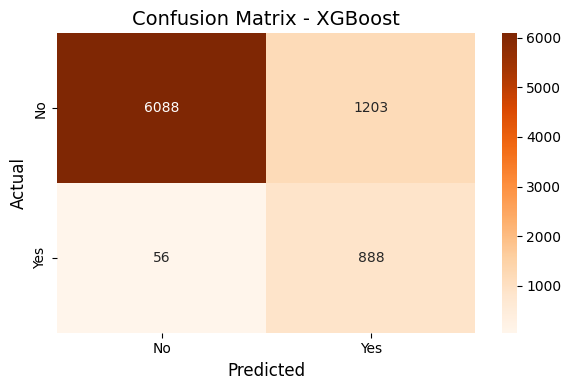

In [79]:
# Confusion Matrix - XGBoost
plt.figure(figsize=(6,4))
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Oranges",
            xticklabels=["No", "Yes"],
            yticklabels=["No", "Yes"])
plt.title("Confusion Matrix - XGBoost", fontsize=14)
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("Actual", fontsize=12)
plt.tight_layout()
plt.savefig("confusion_matrix_xgb.png")
plt.show()

In [51]:
# Model 4 - LightGBM with tuning
import lightgbm as lgb

# Parameter grid
lgbm_param_grid = {
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [3, 4, 5, 6],
    "n_estimators": [100, 200, 300],
    "num_leaves": [31, 50, 70],
    "subsample": [0.7, 0.8, 1.0]
}

lgbm_base = lgb.LGBMClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    verbose=-1
)

lgbm_search = RandomizedSearchCV(
    lgbm_base,
    param_distributions=lgbm_param_grid,
    n_iter=20,
    scoring="recall",  # Same business reasoning as XGBoost
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

lgbm_search.fit(X_train, y_train)
print("Best LightGBM params:", lgbm_search.best_params_)

# Best model predictions
lgbm = lgbm_search.best_estimator_
y_pred_lgbm = lgbm.predict(X_test)
y_prob_lgbm = lgbm.predict_proba(X_test)[:,1]

print("=== LightGBM ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lgbm))
print("Classification Report:")
print(classification_report(y_test, y_pred_lgbm))
print("AUC-ROC:", roc_auc_score(y_test, y_prob_lgbm))

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best LightGBM params: {'subsample': 0.7, 'num_leaves': 70, 'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.05}
=== LightGBM ===
Accuracy: 0.8570734669095325
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.85      0.91      7291
           1       0.44      0.94      0.60       944

    accuracy                           0.86      8235
   macro avg       0.72      0.89      0.76      8235
weighted avg       0.93      0.86      0.88      8235

AUC-ROC: 0.9509346907843197


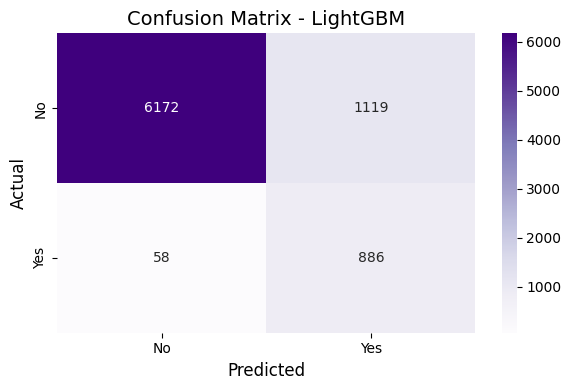

In [52]:
# Confusion Matrix - LightGBM
plt.figure(figsize=(6,4))
cm_lgbm = confusion_matrix(y_test, y_pred_lgbm)
sns.heatmap(cm_lgbm, annot=True, fmt="d", cmap="Purples",
            xticklabels=["No", "Yes"],
            yticklabels=["No", "Yes"])
plt.title("Confusion Matrix - LightGBM", fontsize=14)
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("Actual", fontsize=12)
plt.tight_layout()
plt.savefig("confusion_matrix_lgbm.png")
plt.show()

### 6. Threshold Tuning

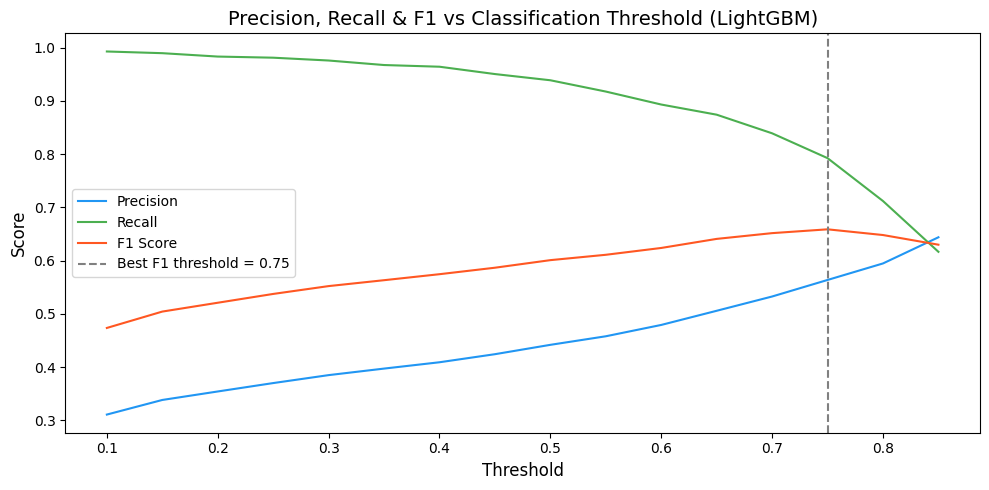

Optimal threshold: 0.75
At this threshold:
              precision    recall  f1-score   support

           0       0.97      0.92      0.95      7291
           1       0.56      0.79      0.66       944

    accuracy                           0.91      8235
   macro avg       0.77      0.86      0.80      8235
weighted avg       0.92      0.91      0.91      8235



In [53]:
# Threshold Tuning on best model (LightGBM)
# Default threshold of 0.5 is rarely optimal for imbalanced data
# Business context: missing a likely subscriber (false negative) costs more
# than contacting an unlikely one (false positive)
from sklearn.metrics import f1_score, precision_score, recall_score

thresholds = np.arange(0.1, 0.9, 0.05)
precisions, recalls, f1s = [], [], []

for thresh in thresholds:
    y_pred_thresh = (y_prob_lgbm >= thresh).astype(int)
    precisions.append(precision_score(y_test, y_pred_thresh, zero_division=0))
    recalls.append(recall_score(y_test, y_pred_thresh, zero_division=0))
    f1s.append(f1_score(y_test, y_pred_thresh, zero_division=0))

# Plot precision, recall, f1 vs threshold
plt.figure(figsize=(10, 5))
plt.plot(thresholds, precisions, label="Precision", color="#2196F3")
plt.plot(thresholds, recalls, label="Recall", color="#4CAF50")
plt.plot(thresholds, f1s, label="F1 Score", color="#FF5722")
plt.axvline(x=thresholds[np.argmax(f1s)], color="gray", linestyle="--",
            label=f"Best F1 threshold = {thresholds[np.argmax(f1s)]:.2f}")
plt.title("Precision, Recall & F1 vs Classification Threshold (LightGBM)", fontsize=14)
plt.xlabel("Threshold", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig("threshold_tuning.png")
plt.show()

best_threshold = thresholds[np.argmax(f1s)]
print(f"Optimal threshold: {best_threshold:.2f}")
print(f"At this threshold:")
y_pred_best = (y_prob_lgbm >= best_threshold).astype(int)
print(classification_report(y_test, y_pred_best))

### 7. SHAP Explainability

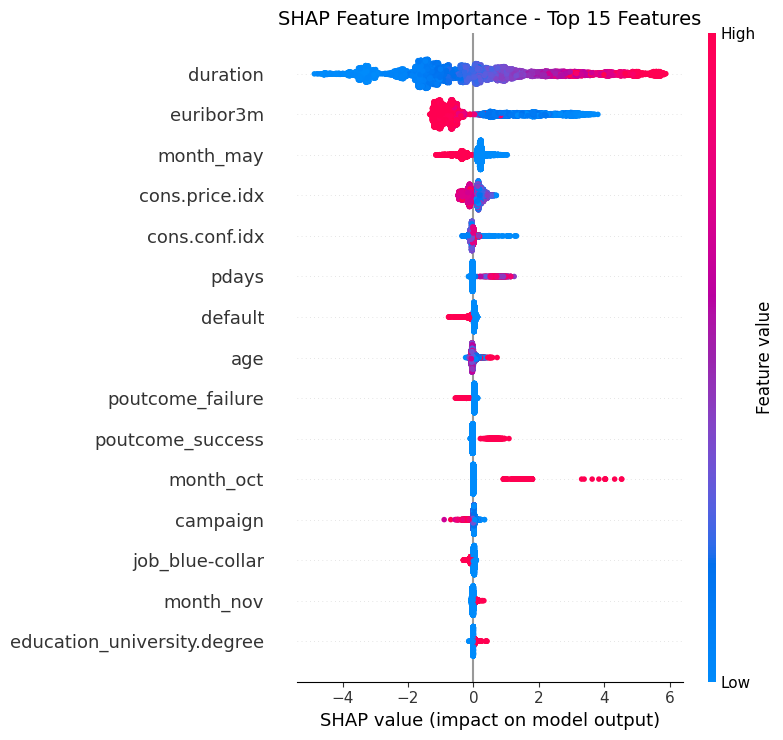

In [54]:
# SHAP Analysis on LightGBM (best model)
# In regulated and business environments, model explainability is critical
# SHAP shows exactly which features drove each prediction
import shap

# Create SHAP explainer
explainer = shap.TreeExplainer(lgbm)
shap_values = explainer.shap_values(X_test)

# Use class 1 (subscribed) SHAP values
shap_vals = shap_values[1] if isinstance(shap_values, list) else shap_values

# Plot 1 - Global Feature Importance (Beeswarm)
plt.figure()
shap.summary_plot(shap_vals, X_test, plot_type="dot", max_display=15, show=False)
plt.title("SHAP Feature Importance - Top 15 Features", fontsize=14)
plt.tight_layout()
plt.savefig("shap_summary.png", bbox_inches="tight")
plt.show()

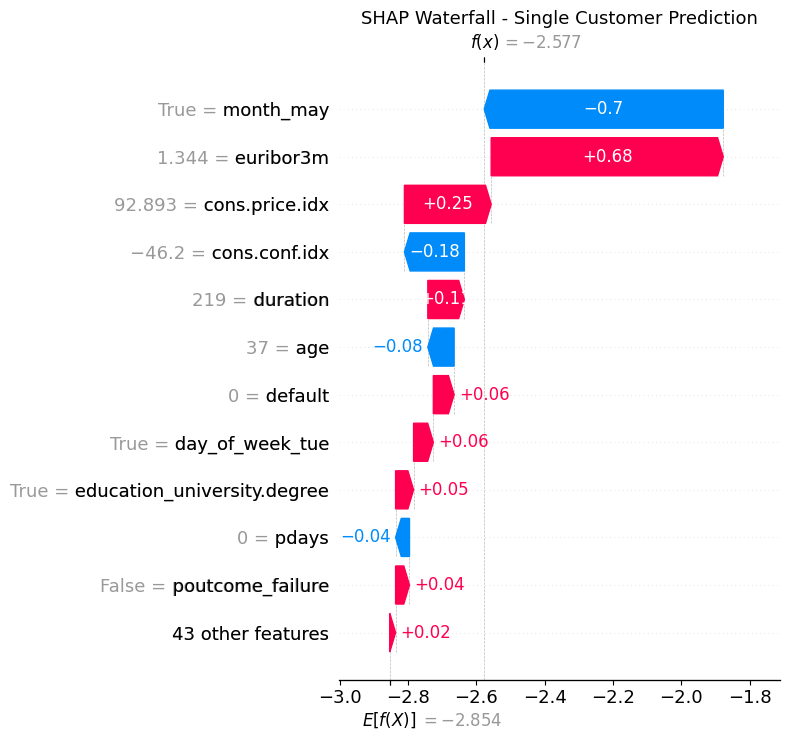

In [55]:
# SHAP Waterfall Plot - Single Prediction Explanation
# Shows exactly why the model made a specific prediction
# This is what would power a real decision-support tool
shap_explanation = shap.Explanation(
    values=shap_vals[0],
    base_values=explainer.expected_value[1] if isinstance(explainer.expected_value, list) else explainer.expected_value,
    data=X_test.iloc[0].values,
    feature_names=X_test.columns.tolist()
)

plt.figure()
shap.waterfall_plot(shap_explanation, max_display=12, show=False)
plt.title("SHAP Waterfall - Single Customer Prediction", fontsize=13)
plt.tight_layout()
plt.savefig("shap_waterfall.png", bbox_inches="tight")
plt.show()

### 8. Model Comparison Summary

In [56]:
# Final Model Comparison Table
# Clear narrative: progression from baseline to best model
from sklearn.metrics import f1_score as f1

results = {
    "Model": ["Logistic Regression", "Random Forest", "XGBoost", "LightGBM"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_lgbm)
    ],
    "Precision (Yes)": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_lgbm)
    ],
    "Recall (Yes)": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_lgbm)
    ],
    "F1 (Yes)": [
        f1(y_test, y_pred_lr),
        f1(y_test, y_pred_rf),
        f1(y_test, y_pred_xgb),
        f1(y_test, y_pred_lgbm)
    ],
    "AUC-ROC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb),
        roc_auc_score(y_test, y_prob_lgbm)
    ]
}

results_df = pd.DataFrame(results)
results_df = results_df.round(4)
results_df = results_df.set_index("Model")
print(results_df.to_string())

# Highlight best model
best_model = results_df["AUC-ROC"].idxmax()
print(f"Best model by AUC-ROC: {best_model}")

                     Accuracy  Precision (Yes)  Recall (Yes)  F1 (Yes)  AUC-ROC
Model                                                                          
Logistic Regression    0.8613           0.4470        0.8845    0.5939   0.9357
Random Forest          0.9127           0.7013        0.4153    0.5216   0.9431
XGBoost                0.8471           0.4247        0.9407    0.5852   0.9472
LightGBM               0.8571           0.4419        0.9386    0.6009   0.9509
Best model by AUC-ROC: LightGBM


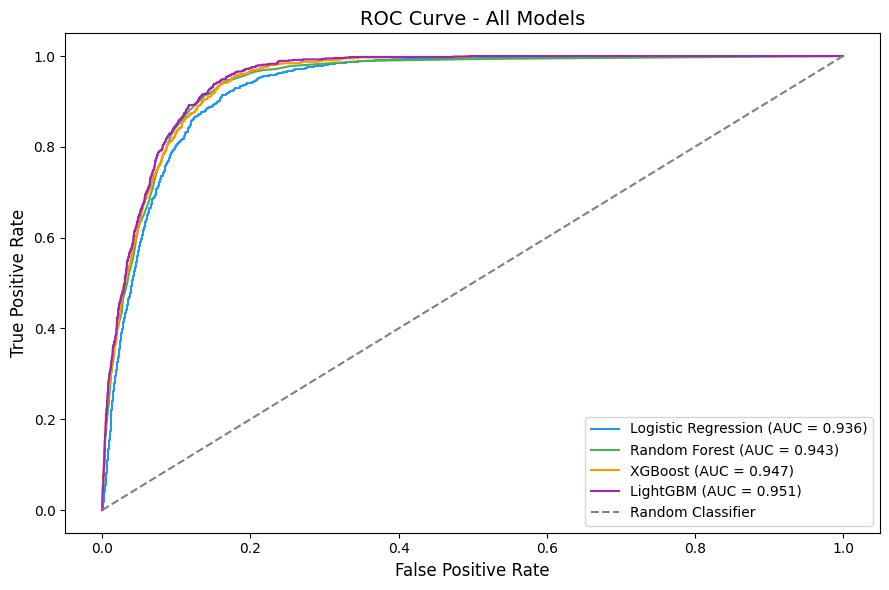

In [57]:
# Updated ROC Curve - All 4 Models
plt.figure(figsize=(9, 6))
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
fpr_lgbm, tpr_lgbm, _ = roc_curve(y_test, y_prob_lgbm)

plt.plot(fpr_lr, tpr_lr, color="#2196F3", label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_lr):.3f})")
plt.plot(fpr_rf, tpr_rf, color="#4CAF50", label=f"Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.3f})")
plt.plot(fpr_xgb, tpr_xgb, color="#FF9800", label=f"XGBoost (AUC = {roc_auc_score(y_test, y_prob_xgb):.3f})")
plt.plot(fpr_lgbm, tpr_lgbm, color="#9C27B0", label=f"LightGBM (AUC = {roc_auc_score(y_test, y_prob_lgbm):.3f})")
plt.plot([0,1], [0,1], color="gray", linestyle="--", label="Random Classifier")
plt.title("ROC Curve - All Models", fontsize=14)
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig("roc_curve_all_models.png")
plt.show()

### 9. Save Best Model for Deployment

In [58]:
# Save best model and feature columns for Streamlit deployment
import pickle

# Save LightGBM model
with open("best_model.pkl", "wb") as f:
    pickle.dump(lgbm, f)

# Save feature column names - needed to align inputs in the app
with open("feature_columns.pkl", "wb") as f:
    pickle.dump(X_train.columns.tolist(), f)

# Save best threshold
with open("best_threshold.pkl", "wb") as f:
    pickle.dump(float(best_threshold), f)

print("Model, feature columns and threshold saved successfully.")
print(f"Features: {len(X_train.columns)}")
print(f"Best threshold: {best_threshold:.2f}")

Model, feature columns and threshold saved successfully.
Features: 54
Best threshold: 0.75
